<a href="https://colab.research.google.com/github/manfredialdo/iad-tpi01/blob/main/Manfredi_Aldo_Comision10_Entrega3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega 3: Visualización de Datos y Análisis de Cancelación de Reservas

**Alumno:** Manfredi, Aldo

**Comisión:** 10

**Número de entrega:** Entrega 3  

**Lenguaje utilizado:** Python  

---
El objetivo no es producir una gran cantidad de gráficos, sino seleccionar algunas visualizaciones que permitan responder preguntas concretas, interpretar patrones y comunicar hallazgos relacionados con la cancelación de reservas.

💻 **Lenguaje de trabajo:** Podés desarrollar la entrega en Python o R. Ambos recorridos son equivalentes y debés utilizar solamente uno.

---

### 📂 Notebook de la Entrega 3
Presentá un notebook independiente y reproducible. No es necesario repetir todo el desarrollo realizado en las Entregas 1 y 2, pero el archivo debe poder ejecutarse desde el comienzo sin depender de otros notebooks.

1. **Datos personales:** Apellido, nombre, comisión y número de entrega.
2. **Lenguaje utilizado:** Python o R.
3. **Bibliotecas:** Importación de las bibliotecas necesarias.
4. **Carga de datos:** Carga del dataset original asignado a la comisión.
5. **Preparación:** Preparación mínima necesaria para reconstruir las variables que utilizarás en las visualizaciones.

---

### 📊 Construí tres visualizaciones

* **Cancelaciones según tipo de hotel:** Construí una visualización que permita comparar reservas canceladas y no canceladas entre los distintos tipos de hotel. Podés reutilizar y mejorar el gráfico elaborado en la Práctica 1.
* **Variable cuantitativa y cancelación:** Elegí una variable cuantitativa relevante (por ejemplo `lead_time`, `adr` o la duración total de la estadía) y construí una visualización que permita analizar su comportamiento en relación con `is_canceled`.
* **Una pregunta propia de análisis:** Elegí otra relación que consideres relevante para comprender el problema de cancelación. Podés trabajar con variables categóricas, temporales o incorporar más de una dimensión mediante color, agrupamiento o facetas.

---

### 📝 Para cada visualización incluí:
* La **pregunta de análisis** que intentás responder.
* Una **breve explicación** de por qué seleccionaste ese tipo de gráfico.
* **Título, ejes y leyenda** claramente identificados cuando corresponda.
* Una **interpretación breve** de los principales patrones, diferencias o relaciones observadas.

---

### 🔎 Cierre del notebook
Finalizá con una síntesis breve en la que identifiques:
* **Tres hallazgos** obtenidos a partir de las visualizaciones.
* Al menos **una limitación o precaución** que deba considerarse antes de elaborar conclusiones más amplias.

---

### ✅ Criterios para revisar antes de entregar
* [ ] El notebook puede ejecutarse desde el inicio.
* [ ] Cada gráfico responde a una pregunta concreta.
* [ ] El tipo de visualización es adecuado para las variables utilizadas.
* [ ] Los gráficos son legibles y están correctamente rotulados.
* [ ] Cada visualización incluye una interpretación escrita.
* [ ] Las conclusiones se desprenden de lo que muestran los datos.
* [ ] El archivo combina código, visualizaciones e interpretación de manera clara y ordenada.

> 💡 **Articulación con la Práctica 1:** No necesitás comenzar desde cero. La visualización construida durante la práctica puede incorporarse a esta entrega después de revisarla y mejorarla a partir de la retroalimentación y de los criterios trabajados durante la semana.

---

### 📤 Condiciones de entrega
* **Habilitación:** Lunes 7 de septiembre de 2026 a las 00:00 hs.
* **Fecha límite:** Domingo 13 de septiembre de 2026 a las 23:59 hs.
* **Formato de archivo:** Notebook en formato `.ipynb`.
* **Nombre sugerido:** `Apellido_Nombre_Comision_Entrega3.ipynb`
* **Calificación mínima de aprobación:** 6 puntos sobre 10.
* **Intentos:** Se admitirán hasta 2 intentos. La reapertura del segundo intento será realizada manualmente por el tutor cuando corresponda.

> 📌 **Importante:** La Entrega 3 es obligatoria y evaluativa, pero su corrección o aprobación no condiciona el acceso a la Semana 7. Incorporá posteriormente las observaciones de tu tutor en el notebook maestro y en las entregas siguientes.

# Trabajo Práctico Integrador - Entrega 3: Visualización de Datos

**Estudiante:** Manfredi Aldo Darío  
**Comisión:** 10  
**Dataset asignado:** `hotel booking TPI grupo J.csv`  
**Variable Objetivo:** `is_canceled` (0 = Concretada, 1 = Cancelada)  

---

## Contexto Metodológico y Fundamentos Teóricos (Unidad N° 3)

1. **Carga y Copia Explícita:** Tal como establece la metodología de trabajo, se conserva el dataset original intacto en la variable `df` y se genera una copia explícita `df_prep` para realizar transformaciones puntuales y visualizaciones, garantizando la reproducibilidad.
2. **Transformaciones Mínimas de Apoyo:** Se crea la variable derivada `total_stay_nights` (noches de semana + fin de semana) y se descartan las reservas inconsistentes sin huéspedes (37 registros detectados en la Entrega 2).
3. **Criterios de Visualización (S6):**
   - **Canales preatentivos:** Se utiliza la posición y la longitud en ejes comunes para comparar cantidades, y el color contrastante (`hue`) para representar la variable binaria de cancelación.
   - **Principios de Expresividad y Efectividad (Mackinlay):** Selección de tipos de gráficos cuya precisión de percepción coincide con el tipo de variable (categórica, cuantitativa o multidimensional), evitando el desorden o sobrecarga cognitiva.

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Carga original intacta
url = "https://raw.githubusercontent.com/manfredialdo/iad-tpi01/main/hotel%20booking%20TPI%20grupo%20J.csv"
df = pd.read_csv(url)

# Copia explícita de trabajo
df_prep = df.copy()

# Transformaciones sobre la copia
df_prep["total_stay_nights"] = (
    df_prep["stays_in_weekend_nights"] + df_prep["stays_in_week_nights"]
)
df_prep = df_prep[
    (
        df_prep["adults"]
        + df_prep["children"].fillna(0)
        + df_prep["babies"].fillna(0)
    )
    > 0
]

print(f"Dataset original cargado: {df.shape[0]} filas.")
print(f"Dataset de trabajo (copia preparada): {df_prep.shape[0]} filas.")

Dataset original cargado: 25000 filas.
Dataset de trabajo (copia preparada): 24963 filas.


Eliminación de reservas sin huéspedes: Se detectaron y descartaron 37 registros inconsistentes en los que la suma de adultos, niños y bebés era igual a 0 (adults + children + babies > 0)


**Impacto en los datos:** El dataset pasó de 25,000 filas en su versión original (df) a 24,963 filas en el dataset preparado para el análisis (df_prep)

## Visualización 1: Cancelaciones según Tipo de Hotel (Mejora de Práctica 1)

### ❓ Pregunta de análisis
¿Existe una diferencia significativa en el volumen absoluto y en la proporciónporcentual de cancelaciones entre el hotel urbano (City Hotel) y el hotelvacacional (Resort Hotel)?


### 📐 Explicación de la selección del gráfico
Se seleccionó un Gráfico de Barras Agrupadas ( countplot ) . Siguiendo el principio de Mackinlay, las barras permiten comparar cantidades categóricas con altaprecisión mediante la longitud y posición. Se añaden etiquetas explícitas deporcentaje intra-grupo para resolver la ambigüedad en la comparación de alturas.

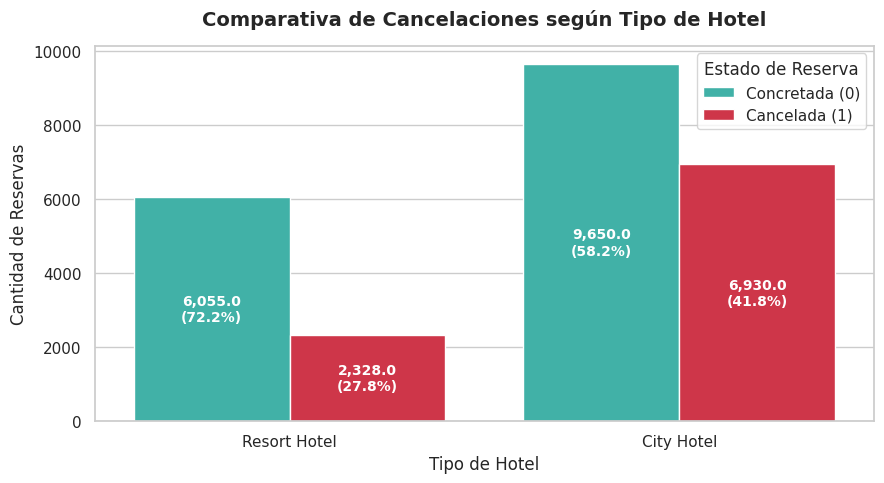

In [14]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df_prep,
    x="hotel",
    hue="is_canceled",
    palette=["#2ec4b6", "#e71d36"],
)

plt.title(
    "Comparativa de Cancelaciones según Tipo de Hotel",
    fontsize=14,
    pad=15,
    fontweight="bold",
)
plt.xlabel("Tipo de Hotel", fontsize=12)
plt.ylabel("Cantidad de Reservas", fontsize=12)

plt.legend(
    title="Estado de Reserva",
    labels=["Concretada (0)", "Cancelada (1)"],
    frameon=True,
)

total_por_hotel = df_prep.groupby("hotel")["is_canceled"].count()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        hotel_cat = "City Hotel" if p.get_x() > 0.5 else "Resort Hotel"
        pct = (height / total_por_hotel[hotel_cat]) * 100
        ax.annotate(
            f"{height:,}\n({pct:.1f}%)",
            (p.get_x() + p.get_width() / 2.0, height / 2),
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

### 💡 Interpretación de patrones observados
- **City Hotel** presenta una tasa de cancelación significativamente más alta (**41.8%**), superando el promedio general del dataset (37.04%).
- **Resort Hotel** muestra mayor estabilidad comercial con una tasa de cancelación de apenas **27.8%**.
- **Insight de negocio:** Las reservas de ciudad presentan una volatilidad mayor (asociada a viajes corporativos o itinerarios flexibles), mientras que las de resort responden a viajes vacacionales planificados con menor arrepentimiento.

## Visualización 2: Variable Cuantitativa (`lead_time`) vs. Cancelación

### ❓ Pregunta de análisis
¿Cómo influye la antelación de la reserva (`lead_time`, en días) en la probabilidad de que la estancia sea efectivamente concretada o cancelada?

### 📐 Explicación de la selección del gráfico
Se utilizó un **Diagrama de Caja (Boxplot)**. La variable `lead_time` tiene asimetría positiva con valores extremos superiores a 300 días. El Boxplot permite comparar medianas, cuartiles y la dispersión (IQR) sin presuponer normalidad en los datos.

--- Estadísticas de Lead Time según Estado de Reserva ---
              25%    50%    75%
is_canceled                    
0             8.0   45.0  126.0
1            49.0  113.0  213.0


/tmp/ipykernel_1545/1903027330.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


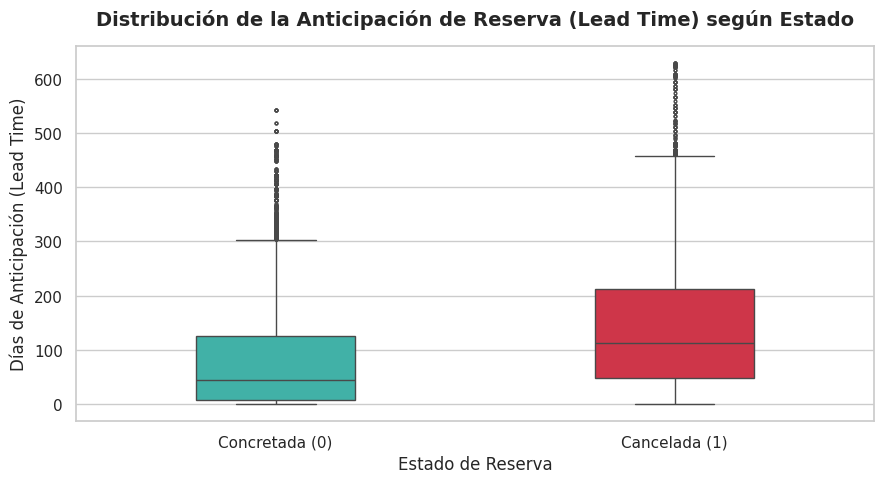

In [12]:
# 1. Cálculo explícito de métricas descriptivas para respaldar el análisis
estadisticos_lead_time = df_prep.groupby("is_canceled")["lead_time"].describe(
    percentiles=[0.25, 0.50, 0.75]
)
print("--- Estadísticas de Lead Time según Estado de Reserva ---")
print(estadisticos_lead_time[["25%", "50%", "75%"]])

# 2. Generación del Boxplot
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_prep,
    x="is_canceled",
    y="lead_time",
    palette=["#2ec4b6", "#e71d36"],
    width=0.4,
    fliersize=2,
)

plt.title(
    "Distribución de la Anticipación de Reserva (Lead Time) según Estado",
    fontsize=14,
    pad=15,
    fontweight="bold",
)
plt.xlabel("Estado de Reserva", fontsize=12)
plt.ylabel("Días de Anticipación (Lead Time)", fontsize=12)
plt.xticks([0, 1], ["Concretada (0)", "Cancelada (1)"])

plt.tight_layout()
plt.show()

### 💡 Interpretación de patrones observados
- **Mediana desplazada:** Las reservas canceladas muestran una mediana de antelación sensiblemente superior (aprox. **113 días**) en comparación con las reservas concretadas (mediana de **45 días**).


Interpretación de patrones observadosDesplazamiento de la mediana: Las reservas canceladas muestran una antelación central sustancialmente mayor (mediana de 113 días) en comparación con las reservas concretadas (mediana de 45 días).

Dispersión del 50% central (IQR): La mitad de las reservas que terminaron en cancelación se realizaron entre 49 días (Q1) y 213 días (Q3) antes del check-in, mientras que en las concretadas dicho rango se reduce significativamente a plazos de entre 8 (Q1) y 126 días (Q3).


Patrón de comportamiento: Existe una relación directa entre el tiempo de anticipación y el riesgo de cancelación: cuanto mayor es la ventana de reserva, mayor es el margen temporal que tiene el usuario para cambiar de planes o buscar alternativas.  - **Patrón detectado:** A mayor tiempo de anticipación entre la reserva y la estadía, mayor es el riesgo de cancelación, dado que el usuario cuenta con margen temporal para cancelar o buscar alternativas.

## Visualización 3: Pregunta Propia (Duración de la Estadía vs. Tipo de Hotel)

### ❓ Pregunta de análisis
¿Existe una relación entre la duración total de la estadía (total_stay_nights) y la tasa de cancelación de la reserva, y cómo varía este comportamiento según el tipo de hotel (hotel)?


### 📐 Explicación de la selección del gráfico
Se seleccionó un Gráfico de Barras Facetado (catplot con kind="bar") filtrado para estadías de hasta 14 noches. La distribución en dos facetas (Resort Hotel vs. City Hotel) permite evaluar simultáneamente una variable discreta, una cuantitativa binaria (convertida a proporción) y una categórica agrupadora sin saturar el gráfico, facilitando la comparación visual directa entre ambos tipos de establecimiento.



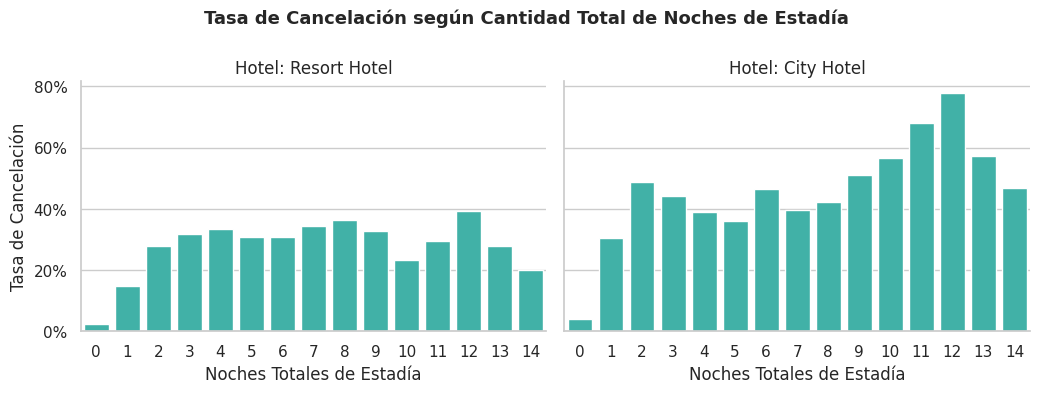

In [15]:
import matplotlib.ticker as mtick

# 1. Filtrar estadías de hasta 14 noches para eliminar outliers extremos
df_estadias = df_prep[df_prep["total_stay_nights"] <= 14].copy()

# 2. Construcción del gráfico de barras facetado por tipo de hotel
g = sns.catplot(
    data=df_estadias,
    x="total_stay_nights",
    y="is_canceled",
    col="hotel",
    kind="bar",
    color="#2ec4b6",
    errorbar=None,
    height=4,
    aspect=1.3,
)

# 3. Ajustes estéticos y formato del eje Y a porcentaje
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle(
    "Tasa de Cancelación según Cantidad Total de Noches de Estadía",
    fontsize=13,
    fontweight="bold",
)

g.set_axis_labels("Noches Totales de Estadía", "Tasa de Cancelación")
g.set_titles(col_template="Hotel: {col_name}")

# Formatear el eje Y como porcentaje (ej. 20%, 40%)
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

### 💡 Interpretación de patrones observados

**Estabilidad y menor riesgo en Resort Hotel:** En el hotel vacacional, la tasa de cancelación se mantiene baja y controlada para casi todas las duraciones, oscilando mayoritariamente entre el 20% y el 35%, alcanzando un pico máximo cercano al 40% en las estadías de 12 noches.


**Tendencia creciente y alta volatilidad en City Hotel:** En el hotel urbano, la tasa de cancelación es sensiblemente superior en todos los plazos y muestra una clara tendencia ascendente a medida que aumenta la estadía. Si bien las estadías cortas (1 a 5 noches) rondan entre el 30% y 50% de cancelación, las reservas de larga duración (9 a 12 noches) sufren un incremento crítico, superando el 60% y alcanzando un pico cercano al 78% en las 12 noches.


**Patrón de negocio:** Las estadías prolongadas en hoteles de ciudad presentan un riesgo de cancelación significativamente mayor, posiblemente asociado a reservas corporativas o itinerarios extensos sujetos a cambios de último momento, a diferencia de los viajes vacacionales en resorts donde la intención de viaje es más firme.

### 💡 Interpretación de patrones observados
